# 该脚本用于给数据添加权重

当数据分布非常不均匀时，例如存在台站或者地震簇，单纯使用TomoATT的内置正则化方法难以完全补偿数据分布不均匀导致的问题。

因此，我们可以通过在外面给数据添加权重的方式，调整不同区域的数据贡献。其核心准则是：

“数据越密的地方，单一数据的权重越低”

注意，差分数据的权重是关联的2个绝对到时数据权重之平均值

In [1]:
# 载入 TomoATT 数据处理函数
import sys
sys.path.append('../utils')
import functions_for_data as ffd

# 1. 读取到时数据文件

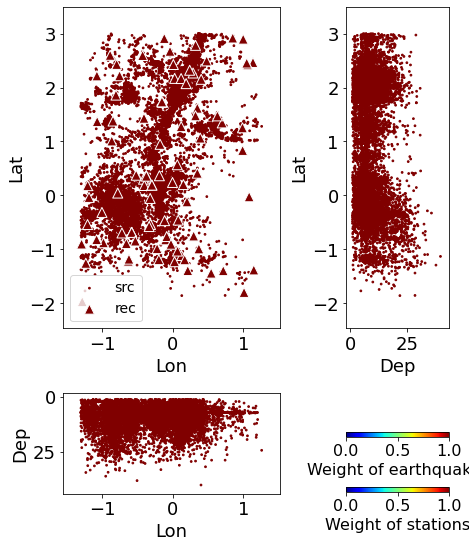

In [2]:
# 读取数据
fname = "output_data/step4_src_rec_Cs.dat"
[ev_info_obs, st_info_obs] = ffd.read_src_rec_file(fname)

# 数据画图，附带权重（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_wt(ev_info_obs, st_info_obs, fname = None)

# 2. 给地震加权重

有2种权重添加方式：

### (a) box weighting （推荐）

做法是将研究区域按照等间距，划分为很多个小的子区域。每个子区域内的地震数量为 N， 该区域内的地震权重设置为 1 / sqrt(N)。

逻辑是数据更大多的地方，数据总权重还是更大 N * 1 / sqrt(N) = sqrt(N), 但是单个数据的权重更小 1 / sqrt(N)

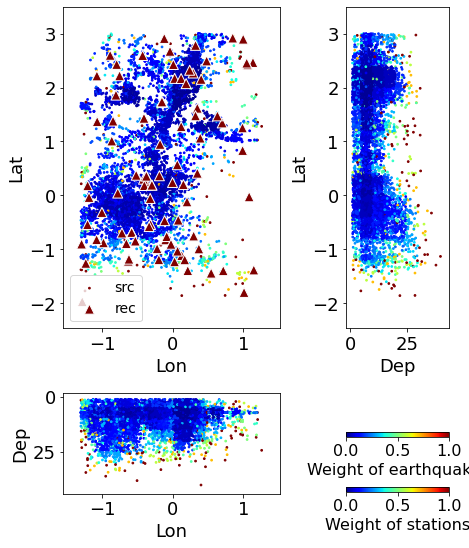

In [3]:
# 子区域的大小为 0.4°×0.4°×5 km, 实施 box weighting
dlon = 0.4; dlat = 0.4; ddep = 5
ev_box = ffd.box_weighting_ev(ev_info_obs,dlon,dlat,ddep)

# 数据画图，附带权重（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_wt(ev_box, st_info_obs, fname = "./figs/step5_ev_box_wt.png")

### (b) geographic weighting （可选）

参考论文

Ruan, Y., Lei, W., Modrak, R., Örsvuran, R., Bozdağ, E., & Tromp, J. (2019). Balancing unevenly distributed data in seismic tomography: a global adjoint tomography example. Geophysical Journal International, 219(2), 1225-1236.

做法是 让每个地震的权重 正相关于 该地震到所有其他地震的距离。

逻辑是，越边缘，地震密度越低的地方，地震距离其他地震的平均距离越大，该地震的权重就越大。

注释1：该权重添加方式比较适合全球成像，在local tomo 里面，在同等数据密度条件下，更容易强化研究区域边缘的地震。（因为研究区域边缘的地震离其他地震的平均距离更远）

注释2：该权重添加方式比 box weighting 更加激进

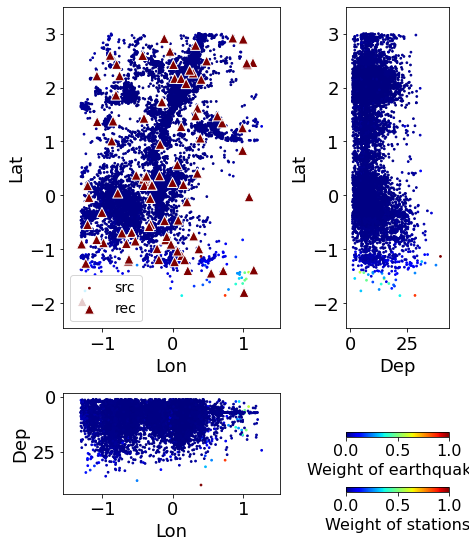

In [4]:
# 由于地震数量角度，两两计算地震距离代价较大，因此进行粗糙的地震权重分布计算，认为同在一个子区域内的地震，位置在同一个位置，即子区域中心。
dlon = 0.2; dlat = 0.2; ddep = 5
ev_geo = ffd.geographical_weighting_ev_rough(ev_info_obs,dlon,dlat,ddep)

# 权重分布画图 plot weight distribution
ffd.fig_ev_st_distribution_wt(ev_geo, st_info_obs, fname = "./figs/step5_ev_geo_wt.png")

# 3. 给台站加权重

和给地震增加权重一样，同样有2种添加形式，这里不再赘述

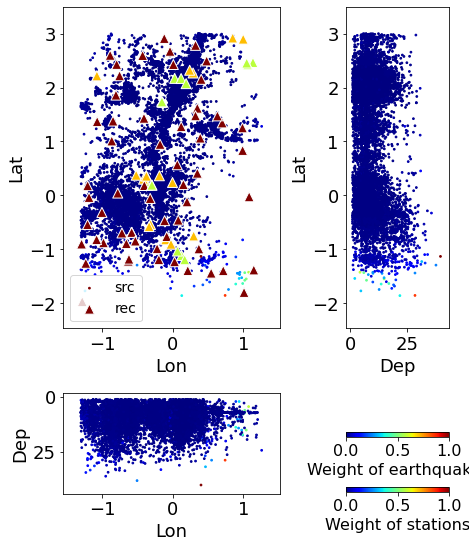

In [5]:
# 给台站加 box weighting
dlon = 0.2; dlat = 0.2; 
(ev_box,st_box) = ffd.box_weighting_st(ev_box,st_info_obs,dlon,dlat)

# 权重分布画图
ffd.fig_ev_st_distribution_wt(ev_box, st_box, fname = "./figs/step5_ev_st_box_wt.png")

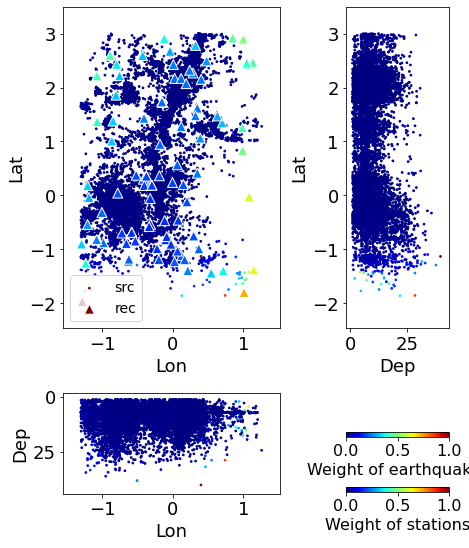

In [6]:
# 给台站加 geographical weighting
# 由于通常台站数量不多，可以两两计算台站间距离
(ev_geo,st_geo) = ffd.geographical_weighting_st(ev_geo,st_info_obs)

# 权重分布画图
ffd.fig_ev_st_distribution_wt(ev_geo, st_geo, fname = "./figs/step5_ev_st_geo_wt.png")

# 4. 文件输出

In [7]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为 TomoATT格式数据文件
out_fname = "%s/step5_src_rec_weight.dat"%(out_path)
ffd.write_src_rec_file(out_fname,ev_info_obs,st_info_obs)

# 地震列表，用于画图
out_fname_ev = "%s/step5_ev_list_weight.dat"%(out_path)
ffd.write_src_list_file(out_fname_ev,ev_info_obs)

# 台站列表，用于画图
out_fname_st = "%s/step5_st_list_weight.dat"%(out_path)
ffd.write_rec_list_file(out_fname_st,ev_info_obs,st_info_obs)

src_rec.dat has been outputed: 20529 events, 92 stations, 152254 abs traveltime, 81812 cs_dif traveltime, 0 cr_dif traveltime. 
earthquake and station region, lat:   -2.0 -    3.0, lon:   -1.3 -    1.3, dep:   -1.9 -   40.0
